## Task Overview

In this lab you will use a **Long Short-Term Memory (LSTM)** network to forecast a
**time series**: monthly totals of international airline passengers from 1949 to
1960 ([Airline Passengers dataset](https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv)).

**After completing this task, you will know how to:**

- Load a time series and prepare it for a recurrent network
- Scale the data correctly (using training statistics only)
- Turn a sequence into **sliding windows** of (past values -> next value)
- Build and train an LSTM for one-step forecasting
- Evaluate the forecast and plot predictions against the real values

**How it's different from image classification:** with time series the **order
matters**. We split the data by time (not randomly), fit the scaler on the
training portion only, and predict a continuous number (regression) instead of a
class.

## Task

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise
indicated. Fill in every cell marked `## Answer here`.

### Static code

In [3]:
# @title Importing Necessary Packages

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [10]:
# @title Device, seed helper, and data URL

# Use a GPU if one is available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    """Fix all random number generators for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# Public URL for the classic Airline Passengers dataset (144 monthly totals).
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

Using device: cpu


### Task 1
#### **Load and prepare the time series (Steps 1-3)**

In this task you will:

1) Load the Airline Passengers data and plot it.
2) Scale the values and split the series chronologically into train and test.
3) Build sliding-window sequences and wrap them in a `DataLoader`.

#### Step 1: Load and plot the data

Read the CSV from `data_url` with `pandas`. The file has two columns, `Month`
and `Passengers`. Extract the `Passengers` column as a float array called
`series` and plot it. You should see an upward trend with a repeating yearly
(seasonal) pattern.

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


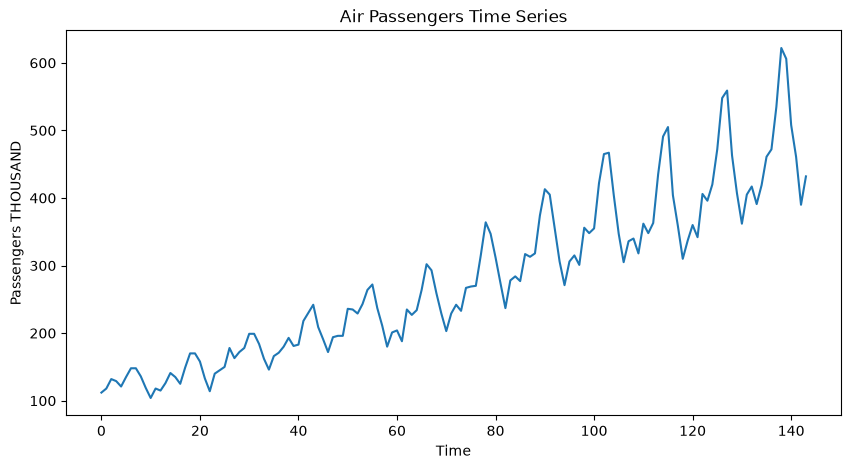

In [29]:
df = pd.read_csv("C:/Users/DELL/Downloads/lab2/airline-passengers.csv")
# Extract passenger values
series = df["Passengers"].values.astype("float32")
# Display first rows
print(df.head())

# Plot the time series
plt.figure(figsize=(10, 5))
plt.plot(series)

plt.xlabel("Time")
plt.ylabel("Passengers THOUSAND")
plt.title("Air Passengers Time Series")

plt.show()

In [32]:
test_size = 12; split_idx = len(series) - test_size
train_raw = series[:split_idx]
test_raw = series[split_idx:]

train_min = train_raw.min()
train_max = train_raw.max()

train_series = (train_raw - train_min) / (train_max - train_min)
test_series = (test_raw - train_min) / (train_max - train_min)

print("Train months:", len(train_series))
print("Test months:", len(test_series))

Train months: 132
Test months: 12


#### Step 3: Build sliding windows and a DataLoader

An LSTM learns from short sub-sequences. Use a window of `seq_length = 12`
months: each input `X` is 12 consecutive months and the target `y` is the very
next month. Build these windows, reshape `X` to `(num_windows, seq_length, 1)`
(the LSTM expects a feature dimension), split them into train/test by their
target month, and wrap the training windows in a `DataLoader` (`batch_size = 16`).

In [35]:
seq_length = 12
# Create sliding windows
def make_windows(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Build windows
X_all, y_all = make_windows(scaled, seq_length)

print("All X shape:", X_all.shape)
print("All y shape:", y_all.shape)

# Split windows based on target month
target_idx = np.arange(seq_length, len(scaled))

train_mask = target_idx < split_idx

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[~train_mask], y_all[~train_mask]

# Convert to tensors and add feature dimension
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

# Check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# DataLoader
train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=False)

All X shape: (132, 12)
All y shape: (132,)
X_train shape: torch.Size([120, 12, 1])
y_train shape: torch.Size([120, 1])
X_test shape: torch.Size([12, 12, 1])
y_test shape: torch.Size([12, 1])


### Task 2
#### **Build the LSTM forecasting model**

Define a model class `LSTMForecaster` that:

1) Runs the input sequence through an `nn.LSTM(input_size=1, hidden_size=50,
   batch_first=True)`.
2) Takes the output of the **last timestep** (it has seen the whole window).
3) Passes it through `nn.Linear(50, 1)` to predict the next value.

In [38]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=50):
        super().__init__()
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (B, seq_length, 1)
        out, _ = self.lstm(x)
        
        # Take output from the last timestep
        last = out[:, -1, :]
        
        # Predict next value
        return self.fc(last)

Check: Instantiate the model and run 5 windows through it. The output shape
should be `torch.Size([5, 1])` (one predicted value per input window).

In [39]:
set_seed(1)                       # reproducible weight initialization
model = LSTMForecaster().to(device)
print(model)

# Quick shape test: run 5 windows through the untrained model.
sample = X_train[:5].to(device)
print("Output shape:", model(sample).shape)   # expect torch.Size([5, 1])

LSTMForecaster(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Output shape: torch.Size([5, 1])


### Task 3
#### **Train the model**

Use **mean squared error** (`nn.MSELoss`) since we're predicting a continuous
value, plus the Adam optimizer. This dataset is tiny, so training many epochs is
fast. Print the loss every few epochs.

In [40]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Number of training epochs
num_epochs = 150

for epoch in range(num_epochs):
    model.train()
    
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        # Move data to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Reset gradients
        optimizer.zero_grad()
        
        # Forward pass
        preds = model(X_batch)
        
        # Compute loss
        loss = criterion(preds, y_batch)
        
        # Backpropagation
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Accumulate loss
        total_loss += loss.item()
    
    # Print average loss every 10 epochs
    avg_loss = total_loss / len(train_loader)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

Epoch [10/150], Loss: 0.014320
Epoch [20/150], Loss: 0.007090
Epoch [30/150], Loss: 0.007679
Epoch [40/150], Loss: 0.005340
Epoch [50/150], Loss: 0.004015
Epoch [60/150], Loss: 0.002959
Epoch [70/150], Loss: 0.006162
Epoch [80/150], Loss: 0.003715
Epoch [90/150], Loss: 0.002823
Epoch [100/150], Loss: 0.003879
Epoch [110/150], Loss: 0.002706
Epoch [120/150], Loss: 0.002535
Epoch [130/150], Loss: 0.001862
Epoch [140/150], Loss: 0.002674
Epoch [150/150], Loss: 0.001890


### Task 4
#### **Evaluate and visualize the forecast**

#### Step 1: Predict and measure error

Put the model in eval mode and predict on `X_test` (inside `torch.no_grad()`).
Convert the predictions and true values back to real passenger counts by
inverting the scaling (`value * (train_max - train_min) + train_min`), then
compute the test **RMSE** (root mean squared error).

In [43]:
import numpy as np

# Put model in evaluation mode
model.eval()

# Predict on test data
with torch.no_grad():
    test_pred = model(X_test.to(device))

# Move predictions to CPU and convert to numpy
test_pred = test_pred.cpu().numpy().flatten()

# Convert true values to numpy
y_test_np = y_test.cpu().numpy().flatten()

# Inverse scaling function
def inverse(x):
    return x * (train_max - train_min) + train_min

# Convert scaled values back to real passenger counts
test_pred_real = inverse(test_pred)
y_test_real = inverse(y_test_np)

# Compute RMSE
rmse = np.sqrt(np.mean((test_pred_real - y_test_real) ** 2))

print("Test RMSE:", rmse)

Test RMSE: 25.950268


#### Step 2: Plot the forecast

Plot the full actual series, then overlay the model's test predictions on the
final 12 months. Add a vertical line at the train/test boundary so it's clear
which part the model never saw during training.

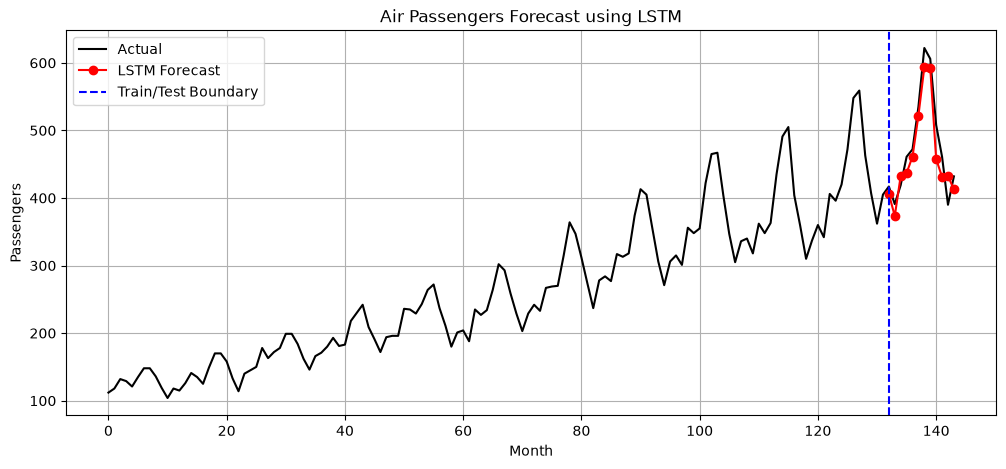

In [44]:
import matplotlib.pyplot as plt

# Month indices for the test period
test_months = np.arange(split_idx, len(series))

plt.figure(figsize=(12, 5))

# Plot actual passenger series
plt.plot(series, color="black", label="Actual")

# Plot model predictions for the final 12 months
plt.plot(
    test_months,
    test_pred_real,
    color="red",
    marker="o",
    label="LSTM Forecast"
)

# Add train/test boundary line
plt.axvline(
    split_idx,
    color="blue",
    linestyle="--",
    label="Train/Test Boundary"
)

# Labels and title
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Air Passengers Forecast using LSTM")

plt.legend()
plt.grid(True)

plt.show()